Churn Modelling Dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
df = pd.read_csv(r"/content/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.drop(['CustomerId','Surname','RowNumber'] , inplace = True , axis = 1)

### مقارنة بين عدد العملاء المتوقع مغادرتهم للبنك وعدد العملاء الذين سيستمرون في التعامل معه.

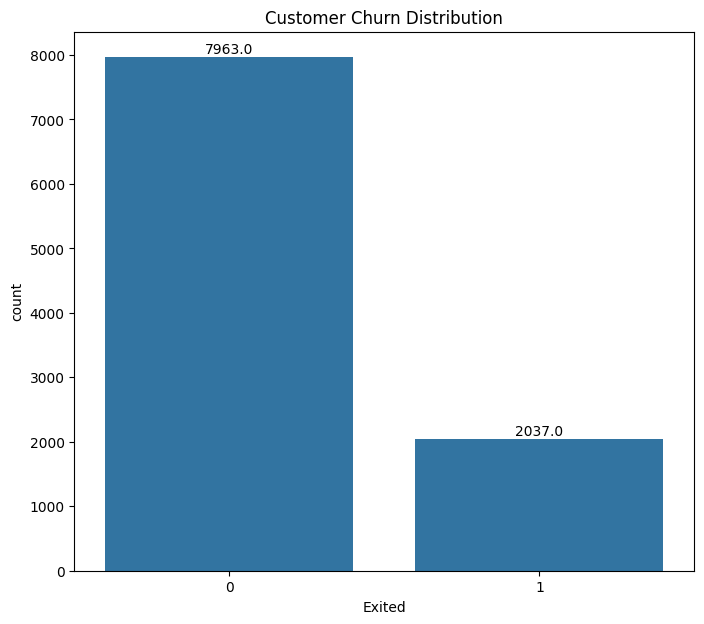

In [ ]:
plt.figure(figsize=(8,7))
bars_customer = sns.countplot(x='Exited', data=df)
for bar in bars_customer.patches:               # To find out the number
    high = bar.get_height()
    plt.text(
        bar.get_x() +  bar.get_width()/2,
        high + 60,
        high,
        ha="center"
    )
plt.title("Customer Churn Distribution")
plt.show()

 ### اكتر دوله لديها عدد من اللذين قد يتركون البنك مقارنه ب عدد العملاء الباقين

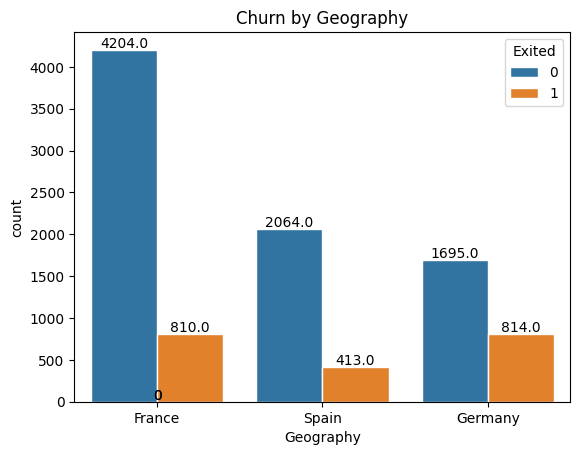

In [ ]:
bars_countries = sns.countplot(x='Geography', hue='Exited', data=df,edgecolor="white")
for bar1 in bars_countries.patches:
    high = bar1.get_height()        # To find out the number
    plt.text(
        bar1.get_x() +  bar1.get_width()/2,
        high+25,
        high,
        ha = "center"
    )
plt.title("Churn by Geography")
plt.show()

### نسبة العملاء من الجنسين ف البنك

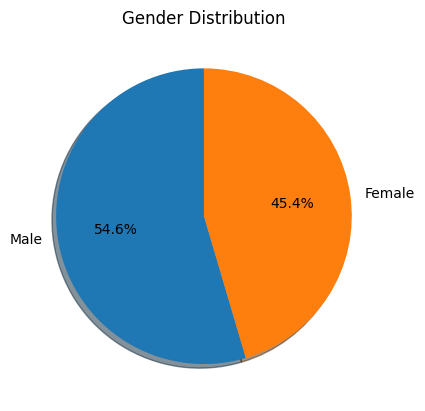

In [ ]:
total_gender = df['Gender'].value_counts()
plt.pie(total_gender, labels=total_gender.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title("Gender Distribution")
plt.show()

### Numbers الي Categories تحويل ال

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['Geography','Gender']])

encoded_df = pd.DataFrame(
encoded,
columns=encoder.get_feature_names_out(['Geography','Gender']),

)

df.drop(['Geography','Gender'], axis=1, inplace=True)
df = pd.concat([encoded_df, df], axis=1)      # Place the columns at the first
df.head(20)

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,0.0,0.0,1.0,0.0,619,42,2,0.00,1,1,1,101348.88,1
1,0.0,0.0,1.0,1.0,0.0,608,41,1,83807.86,1,0,1,112542.58,0
2,1.0,0.0,0.0,1.0,0.0,502,42,8,159660.80,3,1,0,113931.57,1
3,1.0,0.0,0.0,1.0,0.0,699,39,1,0.00,2,0,0,93826.63,0
4,0.0,0.0,1.0,1.0,0.0,850,43,2,125510.82,1,1,1,79084.10,0
5,0.0,0.0,1.0,0.0,1.0,645,44,8,113755.78,2,1,0,149756.71,1
6,1.0,0.0,0.0,0.0,1.0,822,50,7,0.00,2,1,1,10062.80,0
7,0.0,1.0,0.0,1.0,0.0,376,29,4,115046.74,4,1,0,119346.88,1
8,1.0,0.0,0.0,0.0,1.0,501,44,4,142051.07,2,0,1,74940.50,0
9,1.0,0.0,0.0,0.0,1.0,684,27,2,134603.88,1,1,1,71725.73,0


### تجهيز التارجت الي هنشتغل عليه

In [ ]:
x = df.drop('Exited', axis=1)
target = df['Exited']
x_train , x_test , target_train , target_test = train_test_split(x,target , train_size = 0.8 , random_state=42)

### للداتا Scaling عمل

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train

array([[ 1.00150113, -0.57946723, -0.57638802, ...,  0.64920267,
         0.97481699,  1.36766974],
       [-0.99850112,  1.72572313, -0.57638802, ...,  0.64920267,
         0.97481699,  1.6612541 ],
       [-0.99850112, -0.57946723,  1.73494238, ...,  0.64920267,
        -1.02583358, -0.25280688],
       ...,
       [ 1.00150113, -0.57946723, -0.57638802, ..., -1.54035103,
        -1.02583358, -0.1427649 ],
       [ 1.00150113, -0.57946723, -0.57638802, ...,  0.64920267,
        -1.02583358, -0.05082558],
       [-0.99850112,  1.72572313, -0.57638802, ...,  0.64920267,
         0.97481699, -0.81456811]])

## تدريب الموديل

In [ ]:
model = RandomForestClassifier(max_depth=9)
model.fit(x_train, target_train)                #training
target_pred_train = model.predict(x_train)      #predict train
target_pred_test = model.predict(x_test)        #predict test

### train ل  accuracy حساب ال

In [ ]:
print(classification_report(target_pred_train,target_train))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7117
           1       0.50      0.93      0.65       883

    accuracy                           0.89      8000
   macro avg       0.74      0.90      0.79      8000
weighted avg       0.94      0.89      0.90      8000



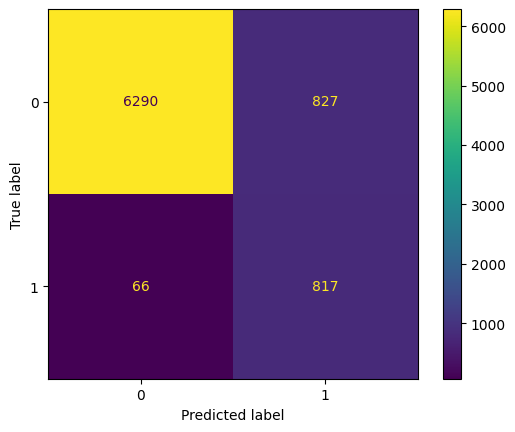

In [ ]:
cm_train = confusion_matrix(target_pred_train,target_train)
ConfusionMatrixDisplay(cm_train).plot();

### test ل  accuracy حساب ال

In [ ]:
print(classification_report(target_pred_test,target_test))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1778
           1       0.43      0.76      0.55       222

    accuracy                           0.86      2000
   macro avg       0.70      0.82      0.73      2000
weighted avg       0.91      0.86      0.88      2000



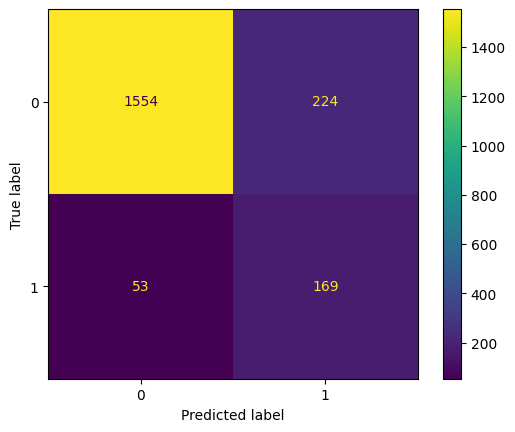

In [ ]:
cm_test = confusion_matrix(target_pred_test,target_test)
ConfusionMatrixDisplay(cm_test).plot();